In [2]:
import duckdb
import pandas as pd
import logging

logging.basicConfig(
    filename='pipeline.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logging.info("Pipeline started")

In [ ]:
DATA_PATH = "/Users/margauxreynolds/Library/CloudStorage/OneDrive-UniversityofVirginia/ds4320-project1-data/ml-25m/"

try:
    con = duckdb.connect()
    con.execute(f"CREATE TABLE ratings AS SELECT * FROM read_csv_auto('{DATA_PATH}ratings.csv')")
    con.execute(f"CREATE TABLE movies AS SELECT * FROM read_csv_auto('{DATA_PATH}movies.csv')")
    con.execute(f"CREATE TABLE tags AS SELECT * FROM read_csv_auto('{DATA_PATH}tags.csv')")
    con.execute(f"CREATE TABLE genome_scores AS SELECT * FROM read_csv_auto('{DATA_PATH}genome-scores.csv')")
    con.execute(f"CREATE TABLE genome_tags AS SELECT * FROM read_csv_auto('{DATA_PATH}genome-tags.csv')")
    con.execute(f"CREATE TABLE links AS SELECT * FROM read_csv_auto('{DATA_PATH}links.csv')")
    logging.info("All tables loaded successfully")
    print("All tables loaded successfully")
except Exception as e:
    logging.error(f"Error loading data: {e}")
    raise

All tables loaded successfully


In [ ]:
print(con.execute("SHOW TABLES").fetchdf())

for table in ['ratings', 'movies', 'tags', 'genome_scores', 'genome_tags', 'links']:
    count = con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"{table}: {count:,} rows")
    logging.info(f"{table}: {count} rows")

            name
0  genome_scores
1    genome_tags
2          links
3         movies
4        ratings
5           tags
ratings: 25,000,095 rows
movies: 62,423 rows
tags: 1,093,360 rows
genome_scores: 15,584,448 rows
genome_tags: 1,128 rows
links: 62,423 rows


In [5]:
# Query: distribution of ratings per movie to show popularity bias
popularity_query = """
    SELECT 
        m.title,
        COUNT(r.rating) AS rating_count,
        AVG(r.rating) AS avg_rating,
        CASE 
            WHEN COUNT(r.rating) < 500 THEN 'Long-tail'
            ELSE 'Popular'
        END AS movie_type
    FROM ratings r
    JOIN movies m ON r.movieId = m.movieId
    GROUP BY m.title
    ORDER BY rating_count DESC
"""

popularity_df = con.execute(popularity_query).fetchdf()
print(popularity_df.head(10))
print(f"\nTotal movies: {len(popularity_df):,}")
print(f"Long-tail movies (fewer than 500 ratings): {len(popularity_df[popularity_df['movie_type'] == 'Long-tail']):,}")
print(f"Popular movies (500+ ratings): {len(popularity_df[popularity_df['movie_type'] == 'Popular']):,}")

                                       title  rating_count  avg_rating  \
0                        Forrest Gump (1994)         81491    4.048011   
1           Shawshank Redemption, The (1994)         81482    4.413576   
2                        Pulp Fiction (1994)         79672    4.188912   
3           Silence of the Lambs, The (1991)         74127    4.151342   
4                         Matrix, The (1999)         72674    4.154099   
5  Star Wars: Episode IV - A New Hope (1977)         68717    4.120189   
6                       Jurassic Park (1993)         64144    3.679175   
7                    Schindler's List (1993)         60411    4.247579   
8                          Braveheart (1995)         59184    4.002273   
9                          Fight Club (1999)         58773    4.228311   

  movie_type  
0    Popular  
1    Popular  
2    Popular  
3    Popular  
4    Popular  
5    Popular  
6    Popular  
7    Popular  
8    Popular  
9    Popular  

Total movies: 58,95

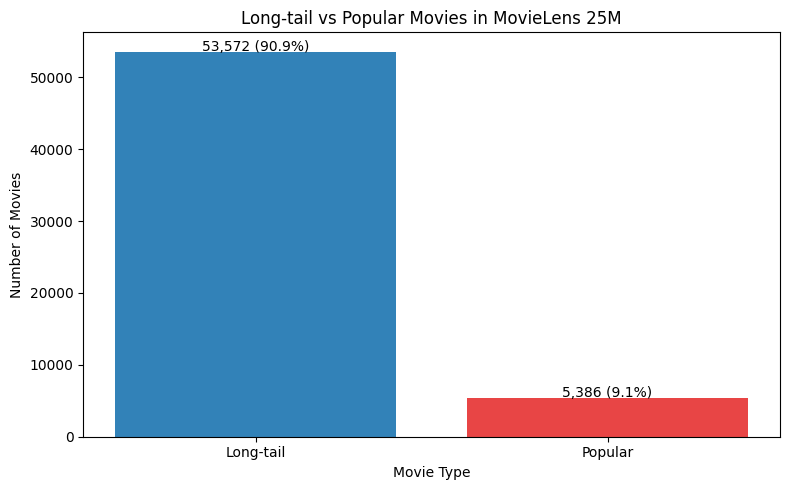

In [6]:
import matplotlib.pyplot as plt

type_counts = popularity_df['movie_type'].value_counts()
percentages = type_counts / type_counts.sum() * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(type_counts.index, type_counts.values, color=['#3282B8', '#E84545'])
plt.xlabel('Movie Type')
plt.ylabel('Number of Movies')
plt.title('Long-tail vs Popular Movies in MovieLens 25M')
for i, (v, p) in enumerate(zip(type_counts.values, percentages)):
    plt.text(i, v + 100, f'{v:,} ({p:.1f}%)', ha='center')
plt.tight_layout()
plt.show()